In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load data (sửa path nếu cần)
df_detail = pd.read_csv('/content/Tiki_be_detail.csv')
df_listing = pd.read_csv('/content/Tiki_be_listing.csv')
df_reviews = pd.read_csv('/content/Tiki_be_reviews.csv')
df_cat = pd.read_csv('/content/Tiki_be_product_id.csv')

# Kiểm tra kiểu dữ liệu của cột product_id trong từng dataframe
print("Kiểu dữ liệu product_id trong df_detail:", df_detail['product_id'].dtype)
print("Kiểu dữ liệu product_id trong df_cat:", df_cat['product_id'].dtype)
print("Kiểu dữ liệu product_id trong df_listing:", df_listing['product_id'].dtype)

# Đồng nhất kiểu dữ liệu: chuyển tất cả về string (hoặc int)
df_detail['product_id'] = df_detail['product_id'].astype(str)
df_cat['product_id'] = df_cat['product_id'].astype(str)
df_listing['product_id'] = df_listing['product_id'].astype(str)

# (Optional) Nếu df_reviews cũng có product_id, chuyển luôn
if 'product_id' in df_reviews.columns:
    df_reviews['product_id'] = df_reviews['product_id'].astype(str)

# Merge cơ bản để phân tích
df_prod = df_detail.merge(df_cat, on='product_id', how='left')
df_prod = df_prod.merge(df_listing, on='product_id', how='left')

# Kiểm tra kết quả merge
print("\n✅ Merge thành công!")
print(f"Shape của df_prod: {df_prod.shape}")
print(f"\nCác cột trong df_prod:\n{df_prod.columns.tolist()}")
print(f"\n5 dòng đầu tiên:\n{df_prod.head()}")

Kiểu dữ liệu product_id trong df_detail: object
Kiểu dữ liệu product_id trong df_cat: int64
Kiểu dữ liệu product_id trong df_listing: int64

✅ Merge thành công!
Shape của df_prod: (1879, 36)

Các cột trong df_prod:
['product_id', 'sku', 'name', 'short_description', 'price', 'list_price', 'discount', 'discount_rate', 'rating_average', 'review_count', 'order_count', 'stock_qty', 'max_sale_qty', 'brand_id', 'brand_name', 'inventory_status', 'is_visible', 'product_url', 'description', 'specifications', 'seller_id', 'seller_name', 'seller_type', 'seller_rating', 'seller_review_count', 'seller_product_count', 'seller_is_official', 'seller_link', 'category_lv1', 'category_lv2', 'category_lv3', 'category_id_x', 'category_id_y', 'product_name', 'quantity_sold', 'quantity_sold_text']

5 dòng đầu tiên:
  product_id            sku  \
0  278631185  9551760000000   
1  277775750  7900750000000   
2  277775605  3535370000000   
3  277725874  1414690000000   
4  277543166  4552810000000   

          

In [13]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load data
df_detail = pd.read_csv('/content/Tiki_be_detail.csv')
df_listing = pd.read_csv('/content/Tiki_be_listing.csv')
df_reviews = pd.read_csv('/content/Tiki_be_reviews.csv')
df_cat = pd.read_csv('/content/Tiki_be_product_id.csv')

# ========== 1. TỔNG QUAN KÍCH THƯỚC DỮ LIỆU ==========
print("="*80)
print("📊 TỔNG QUAN DỮ LIỆU SẢN PHẨM TRẺ SƠ SINH TRÊN TIKI")
print("="*80)

datasets = {
    'Tiki_be_detail': df_detail,
    'Tiki_be_listing': df_listing,
    'Tiki_be_reviews': df_reviews,
    'Tiki_be_product_id': df_cat
}

overview_df = pd.DataFrame({
    'Dataset': list(datasets.keys()),
    'Số dòng': [df.shape[0] for df in datasets.values()],
    'Số cột': [df.shape[1] for df in datasets.values()],
    'Số missing values': [df.isna().sum().sum() for df in datasets.values()],
    '% missing': [(df.isna().sum().sum() / (df.shape[0] * df.shape[1]) * 100) for df in datasets.values()]
})

print("\n📌 KÍCH THƯỚC CÁC BẢNG DỮ LIỆU:")
print(overview_df.to_string(index=False))
print(f"\n✅ Tổng số sản phẩm (unique product_id từ detail): {df_detail['product_id'].nunique():,}")
print(f"✅ Tổng số đánh giá (reviews): {len(df_reviews):,}")
print(f"✅ Tổng số danh mục (category): {df_cat['category_id'].nunique():,}")

# ========== 2. THỐNG KÊ CƠ BẢN CHO TỪNG BẢNG ==========
print("\n" + "="*80)
print("📌 CHI TIẾT TỪNG BẢNG DỮ LIỆU")
print("="*80)

# 2.1 Bảng detail
print("\n🔹 BẢNG Tiki_be_detail (Chi tiết sản phẩm):")
print(f"   - Số sản phẩm: {len(df_detail):,}")
print(f"   - Số thương hiệu: {df_detail['brand_name'].nunique():,}")
print(f"   - Số người bán: {df_detail['seller_id'].nunique():,}")
print(f"   - Khoảng giá: {df_detail['price'].astype(str).str.replace(',','').str.extract('(\\d+)').iloc[:,0].astype(float).min():,.0f} - {df_detail['price'].astype(str).str.replace(',','').str.extract('(\\d+)').iloc[:,0].astype(float).max():,.0f} VND")
print(f"   - Sản phẩm còn hàng: {df_detail[df_detail['inventory_status'] == 'available'].shape[0]:,} ({df_detail[df_detail['inventory_status'] == 'available'].shape[0]/len(df_detail)*100:.1f}%)")

# 2.2 Bảng listing
print("\n🔹 BẢNG Tiki_be_listing (Thông tin bán hàng):")
print(f"   - Số dòng: {len(df_listing):,}")
print(f"   - Số sản phẩm unique: {df_listing['product_id'].nunique():,}")
print(f"   - Tổng lượng bán (quantity_sold_text): {df_listing['quantity_sold_text'].value_counts().head(3).to_dict()}")

# 2.3 Bảng reviews
print("\n🔹 BẢNG Tiki_be_reviews (Đánh giá khách hàng):")
print(f"   - Số review: {len(df_reviews):,}")
print(f"   - Số khách hàng unique: {df_reviews['customer_id'].nunique():,}")
print(f"   - Số sản phẩm được đánh giá: {df_reviews['product_id'].nunique():,}")
print(f"   - Rating trung bình: {df_reviews['rating'].mean():.2f} / 5.0")
print(f"   - Review có ảnh: {df_reviews[df_reviews['images_count'] > 0].shape[0]:,} ({df_reviews[df_reviews['images_count'] > 0].shape[0]/len(df_reviews)*100:.1f}%)")
print(f"   - Review verified: {df_reviews[df_reviews['is_verified'] == True].shape[0]:,} ({df_reviews[df_reviews['is_verified'] == True].shape[0]/len(df_reviews)*100:.1f}%)")

# 2.4 Bảng category
print("\n🔹 BẢNG Tiki_be_product_id (Phân loại sản phẩm):")
print(f"   - Số dòng: {len(df_cat):,}")
print(f"   - Số sản phẩm: {df_cat['product_id'].nunique():,}")
print(f"   - Số category cấp 1: {df_cat['category_lv1'].nunique():,}")
print(f"   - Số category cấp 2: {df_cat['category_lv2'].nunique():,}")
print(f"   - Số category cấp 3: {df_cat['category_lv3'].nunique():,}")

# ========== 3. THỐNG KÊ MISSING VALUES ==========
print("\n" + "="*80)
print("📌 PHÂN TÍCH MISSING VALUES")
print("="*80)

for name, df in datasets.items():
    missing = df.isna().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({'Cột': missing.index, 'Số missing': missing.values, 'Tỷ lệ %': missing_pct.values})
    missing_df = missing_df[missing_df['Số missing'] > 0].sort_values('Tỷ lệ %', ascending=False)

    if len(missing_df) > 0:
        print(f"\n🔸 {name}:")
        print(missing_df.to_string(index=False))
    else:
        print(f"\n🔸 {name}: ✅ Không có missing values")

# ========== 4. THỐNG KÊ PHÂN PHỐI CƠ BẢN ==========
print("\n" + "="*80)
print("📌 PHÂN PHỐI CÁC CHỈ SỐ QUAN TRỌNG")
print("="*80)

# 4.1 Phân phối rating
print("\n🔸 PHÂN PHỐI ĐÁNH GIÁ (RATING):")
rating_dist = df_reviews['rating'].value_counts().sort_index()
for rating, count in rating_dist.items():
    pct = (count / len(df_reviews)) * 100
    bar = '█' * int(pct / 2)
    print(f"   {rating} sao: {count:6,} ({pct:5.1f}%) {bar}")

# 4.2 Top 10 thương hiệu có nhiều sản phẩm nhất
print("\n🔸 TOP 10 THƯƠNG HIỆU CÓ NHIỀU SẢN PHẨM NHẤT:")
top_brands = df_detail['brand_name'].value_counts().head(10)
for i, (brand, count) in enumerate(top_brands.items(), 1):
    print(f"   {i:2}. {brand[:30]:30} : {count:3} sản phẩm")

# 4.3 Phân phối category cấp 1
print("\n🔸 PHÂN PHỐI DANH MỤC CẤP 1:")
cat_lv1_dist = df_cat['category_lv1'].value_counts()
for cat, count in cat_lv1_dist.items():
    pct = (count / len(df_cat)) * 100
    print(f"   {cat[:35]:35} : {count:5,} ({pct:5.1f}%)")

# 4.4 Thời gian đánh giá
print("\n🔸 THỜI GIAN ĐÁNH GIÁ:")
df_reviews['created_at_date'] = pd.to_datetime(df_reviews['created_at_date'])
print(f"   - Ngày sớm nhất: {df_reviews['created_at_date'].min().strftime('%d/%m/%Y')}")
print(f"   - Ngày mới nhất: {df_reviews['created_at_date'].max().strftime('%d/%m/%Y')}")
print(f"   - Khoảng thời gian: {(df_reviews['created_at_date'].max() - df_reviews['created_at_date'].min()).days} ngày")

# ========== 5. THỐNG KÊ NHANH ==========
print("\n" + "="*80)
print("📌 KẾT LUẬN NHANH")
print("="*80)

print(f"""
✅ Tổng số sản phẩm: {df_detail['product_id'].nunique():,}
✅ Tổng số đánh giá: {len(df_reviews):,}
✅ Đánh giá trung bình: {df_reviews['rating'].mean():.2f}/5.0
✅ Tỷ lệ review có ảnh: {df_reviews[df_reviews['images_count'] > 0].shape[0]/len(df_reviews)*100:.1f}%
✅ Tỷ lệ review verified: {df_reviews[df_reviews['is_verified'] == True].shape[0]/len(df_reviews)*100:.1f}%
✅ Số thương hiệu: {df_detail['brand_name'].nunique():,}
✅ Số người bán: {df_detail['seller_id'].nunique():,}
✅ Số khách hàng đánh giá: {df_reviews['customer_id'].nunique():,}
""")

print("="*80)
print("✅ HOÀN THÀNH PHÂN TÍCH TỔNG QUAN DỮ LIỆU")
print("="*80)

📊 TỔNG QUAN DỮ LIỆU SẢN PHẨM TRẺ SƠ SINH TRÊN TIKI

📌 KÍCH THƯỚC CÁC BẢNG DỮ LIỆU:
           Dataset  Số dòng  Số cột  Số missing values  % missing
    Tiki_be_detail     1878      28              11605  22.069451
   Tiki_be_listing     5037       5               1785   7.087552
   Tiki_be_reviews    74036      16              46541   3.928916
Tiki_be_product_id     1620       5                  0   0.000000

✅ Tổng số sản phẩm (unique product_id từ detail): 1,873
✅ Tổng số đánh giá (reviews): 74,036
✅ Tổng số danh mục (category): 23

📌 CHI TIẾT TỪNG BẢNG DỮ LIỆU

🔹 BẢNG Tiki_be_detail (Chi tiết sản phẩm):
   - Số sản phẩm: 1,878
   - Số thương hiệu: 367
   - Số người bán: 249
   - Khoảng giá: 1 - 10,432,000 VND
   - Sản phẩm còn hàng: 1,849 (98.5%)

🔹 BẢNG Tiki_be_listing (Thông tin bán hàng):
   - Số dòng: 5,037
   - Số sản phẩm unique: 5,037
   - Tổng lượng bán (quantity_sold_text): {'Đã bán 1': 490, 'Đã bán 2': 247, 'Đã bán 3': 194}

🔹 BẢNG Tiki_be_reviews (Đánh giá khách hàng):
 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df_detail = pd.read_csv('/content/Tiki_be_detail.csv')
df_cat = pd.read_csv('/content/Tiki_be_product_id.csv')

# Chuyển đổi product_id sang string để đồng nhất
df_detail['product_id'] = df_detail['product_id'].astype(str)
df_cat['product_id'] = df_cat['product_id'].astype(str)

# Lấy danh sách unique product_id
detail_products = set(df_detail['product_id'].unique())
cat_products = set(df_cat['product_id'].unique())

# Phân tích intersection
common_products = detail_products.intersection(cat_products)
only_in_detail = detail_products - cat_products
only_in_cat = cat_products - detail_products

print("="*80)
print("🔍 PHÂN TÍCH SỰ KHÁC BIỆT GIỮA 2 BẢNG")
print("="*80)
print(f"\n📌 Số sản phẩm trong detail: {len(detail_products):,}")
print(f"📌 Số sản phẩm trong product_id table: {len(cat_products):,}")
print(f"📌 Số sản phẩm chung: {len(common_products):,}")
print(f"\n⚠️ Sản phẩm chỉ có trong detail (không có category): {len(only_in_detail):,}")
print(f"⚠️ Sản phẩm chỉ có trong category table (không có detail): {len(only_in_cat):,}")

# Hiển thị 10 sản phẩm đầu tiên chỉ có trong detail
if len(only_in_detail) > 0:
    print(f"\n🔸 10 sản phẩm đầu tiên chỉ có trong detail (không category):")
    sample_missing = list(only_in_detail)[:10]
    for pid in sample_missing:
        product_info = df_detail[df_detail['product_id'] == pid][['name', 'brand_name']].iloc[0]
        print(f"   - ID: {pid} | {product_info['name'][:50]} | {product_info['brand_name']}")

# Kiểm tra phân phối số lượng category mỗi sản phẩm
print("\n" + "="*80)
print("📊 PHÂN TÍCH QUAN HỆ 1-NHIỀU (1 sản phẩm - nhiều category)")
print("="*80)

# Đếm số category cho mỗi product_id trong bảng product_id
cat_counts = df_cat['product_id'].value_counts()
print(f"\n🔸 Số lượng category trung bình mỗi sản phẩm: {cat_counts.mean():.2f}")
print(f"🔸 Số lượng category tối đa cho 1 sản phẩm: {cat_counts.max()}")
print(f"🔸 Số lượng category tối thiểu: {cat_counts.min()}")

# Phân phối số lượng category
print(f"\n🔸 PHÂN PHỐI SỐ LƯỢNG CATEGORY PER PRODUCT:")
dist = cat_counts.value_counts().sort_index()
for num_cat, count in dist.items():
    pct = (count / len(cat_counts)) * 100
    print(f"   {num_cat} category: {count:4} sản phẩm ({pct:5.1f}%)")

# Hiển thị ví dụ sản phẩm có nhiều category nhất
if len(cat_counts) > 0:
    max_cat_product = cat_counts.idxmax()
    max_cat_count = cat_counts.max()
    print(f"\n🔸 Ví dụ sản phẩm có {max_cat_count} category:")
    product_example = df_cat[df_cat['product_id'] == max_cat_product]
    print(f"   Product ID: {max_cat_product}")
    for idx, row in product_example.iterrows():
        print(f"   - Category LV1: {row['category_lv1']} | LV2: {row['category_lv2']} | LV3: {row['category_lv3']}")

print("\n" + "="*80)
print("📌 KẾT LUẬN:")
print("="*80)
print(f"""
✅ Điều này là BÌNH THƯỜNG trong dữ liệu thương mại điện tử
✅ Mỗi sản phẩm có thể có {cat_counts.mean():.1f} category trung bình
✅ Có {len(only_in_detail)} sản phẩm chưa được phân loại (cần xử lý sau)
✅ Có {len(only_in_cat)} sản phẩm trong category nhưng không có detail (có thể đã ngừng bán)

💡 **Khuyến nghị khi phân tích:**
1. Dùng INNER JOIN nếu chỉ muốn sản phẩm có đầy đủ thông tin
2. Dùng LEFT JOIN nếu muốn giữ tất cả sản phẩm từ detail
3. Các sản phẩm không có category có thể gán vào nhóm "Chưa phân loại"
""")

Top brand theo số lượng sản phẩm

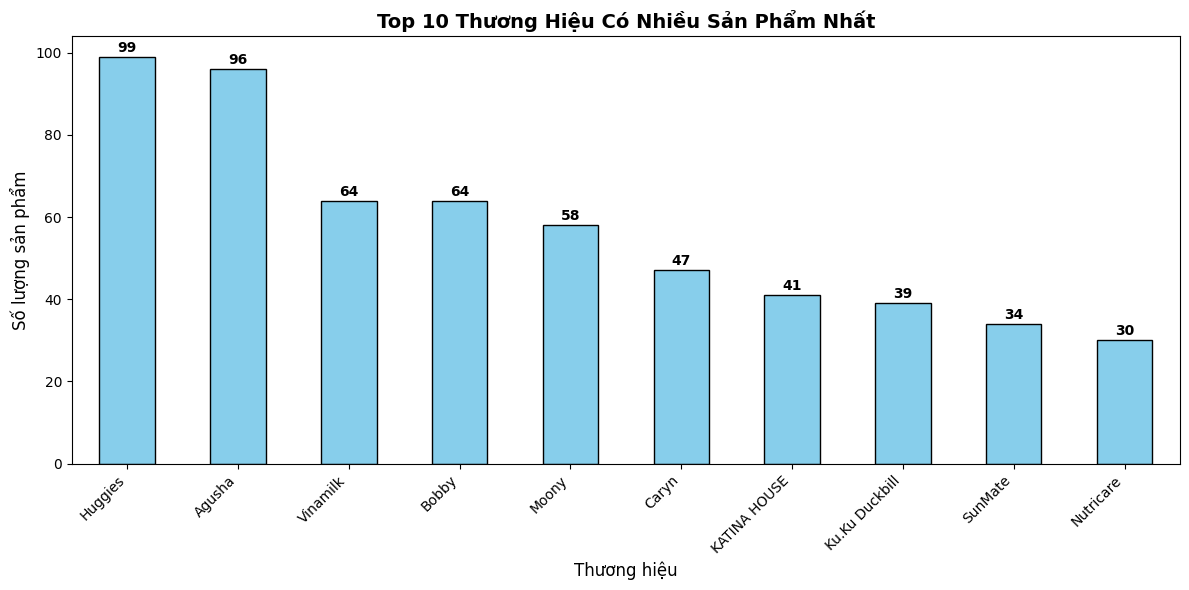

brand_name
Huggies           99
Agusha            96
Vinamilk          64
Bobby             64
Moony             58
Caryn             47
KATINA HOUSE      41
Ku.Ku Duckbill    39
SunMate           34
Nutricare         30
Name: count, dtype: int64


In [15]:
import matplotlib.pyplot as plt
import pandas as pd

top_brand = df_detail['brand_name'].value_counts().head(10)

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
ax = top_brand.plot(kind='bar', color='skyblue', edgecolor='black')

# Thêm số liệu lên từng cột
for i, (brand, count) in enumerate(top_brand.items()):
    ax.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Top 10 Thương Hiệu Có Nhiều Sản Phẩm Nhất', fontsize=14, fontweight='bold')
plt.xlabel('Thương hiệu', fontsize=12)
plt.ylabel('Số lượng sản phẩm', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(top_brand)

Biểu đồ phân phối giá sản phẩm theo từng category_lv2

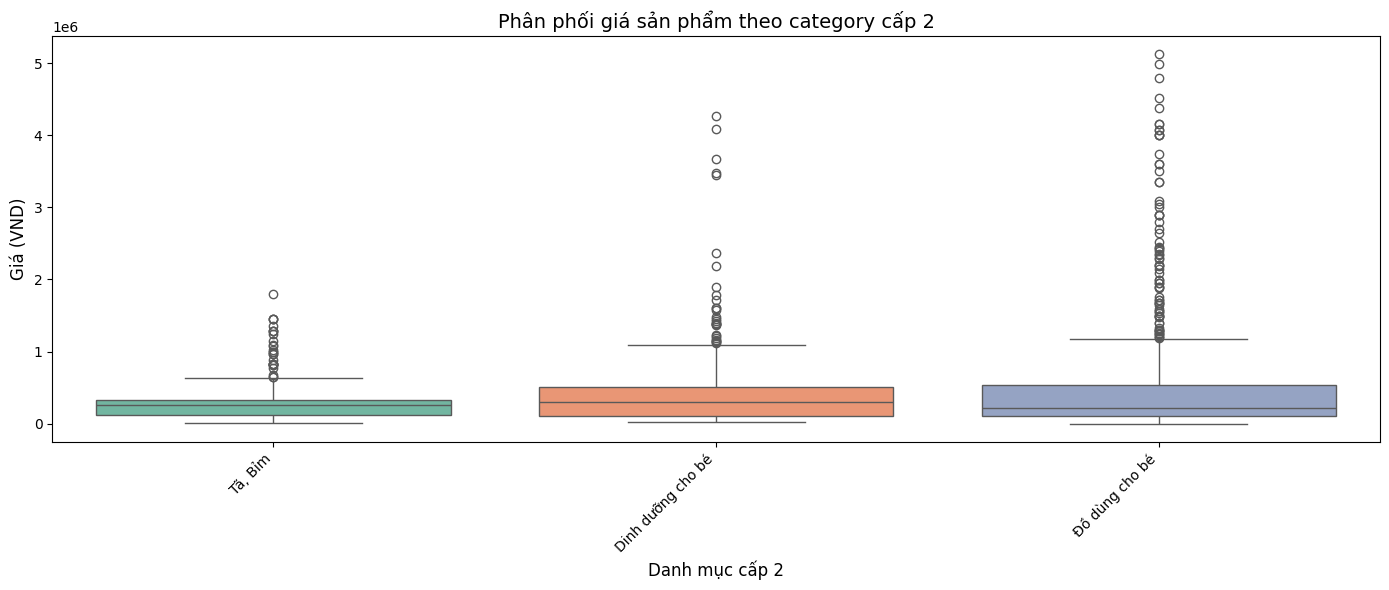

📊 Giá trị thống kê giá theo category_lv2:
                     min     25%     50%     75%      max
category_lv2                                             
Dinh dưỡng cho bé  19000  110000  296000  506000  4270000
Tã, Bỉm             6900  125000  259000  330000  1800000
Đồ dùng cho bé      2000  102000  212800  536250  5121000

📌 Tổng số sản phẩm sau khi lọc: 1600
📌 Khoảng giá từ 2,000 đến 5,121,000 VND

✅ KIỂU DỮ LIỆU SAU KHI XỬ LÝ:
price             float64
discount_rate     float64
rating_average    float64
review_count      float64
order_count       float64
dtype: object


In [7]:

# ========== XỬ LÝ CHUYỂN ĐỔI KIỂU DỮ LIỆU ==========

# Hàm chuyển đổi price từ string sang number
def convert_price(price_str):
    if pd.isna(price_str):
        return np.nan
    # Loại bỏ ký tự đặc biệt: dấu phẩy, khoảng trắng, 'đ', '₫', 'VND'
    price_str = str(price_str).replace(',', '').replace('.', '').replace(' ', '')
    price_str = price_str.replace('đ', '').replace('₫', '').replace('VND', '').strip()
    try:
        return float(price_str)
    except:
        return np.nan

# Chuyển đổi cột price
df_prod['price'] = df_prod['price'].apply(convert_price)

# Chuyển đổi các cột số khác nếu cần
numeric_cols = ['discount', 'discount_rate', 'rating_average', 'review_count',
                'order_count', 'stock_qty', 'max_sale_qty', 'quantity_sold']

for col in numeric_cols:
    if col in df_prod.columns:
        # Thử chuyển sang số, nếu lỗi thì bỏ qua
        df_prod[col] = pd.to_numeric(df_prod[col], errors='coerce')

# ========== BIỂU ĐỒ 1: PHÂN PHỐI GIÁ THEO CATEGORY ==========

# Loại bỏ các dòng có price bị NaN hoặc quá cao
df_price = df_prod[df_prod['price'].notna()].copy()
if len(df_price) > 0:
    # Loại outlier giá cực cao (99th percentile)
    price_99 = df_price['price'].quantile(0.99)
    df_price = df_price[df_price['price'] < price_99]

    # Kiểm tra category_lv2 có dữ liệu không
    df_price = df_price[df_price['category_lv2'].notna()]

    if len(df_price) > 0:
        plt.figure(figsize=(14,6))
        sns.boxplot(data=df_price, x='category_lv2', y='price', palette='Set2')
        plt.xticks(rotation=45, ha='right')
        plt.title('Phân phối giá sản phẩm theo category cấp 2', fontsize=14)
        plt.ylabel('Giá (VND)', fontsize=12)
        plt.xlabel('Danh mục cấp 2', fontsize=12)
        plt.tight_layout()
        plt.show()

        # Chỉ số thống kê
        price_stats = df_price.groupby('category_lv2')['price'].describe()
        print("📊 Giá trị thống kê giá theo category_lv2:")
        print(price_stats[['min','25%','50%','75%','max']].round(0).astype(int))

        # In thêm thông tin
        print(f"\n📌 Tổng số sản phẩm sau khi lọc: {len(df_price)}")
        print(f"📌 Khoảng giá từ {df_price['price'].min():,.0f} đến {df_price['price'].max():,.0f} VND")
    else:
        print("⚠️ Không có dữ liệu category_lv2 sau khi lọc")
else:
    print("⚠️ Không có dữ liệu price hợp lệ")

# ========== HIỂN THỊ THÔNG TIN KIỂU DỮ LIỆU ==========
print("\n" + "="*50)
print("✅ KIỂU DỮ LIỆU SAU KHI XỬ LÝ:")
print(df_prod[['price', 'discount_rate', 'rating_average', 'review_count', 'order_count']].dtypes)
print("="*50)

Biểu đồ số lượng đánh giá (review_count) theo thang rating (1–5) từ df_reviews

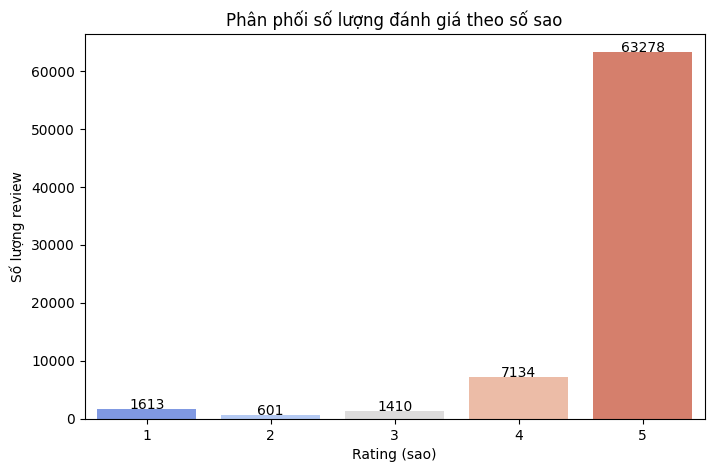

📊 Tỷ lệ % từng mức rating:
rating
1     2.18
2     0.81
3     1.90
4     9.64
5    85.47
Name: count, dtype: float64


In [8]:
rating_counts = df_reviews['rating'].value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='coolwarm')
plt.title('Phân phối số lượng đánh giá theo số sao')
plt.xlabel('Rating (sao)')
plt.ylabel('Số lượng review')
for i, v in enumerate(rating_counts.values):
    plt.text(i, v+10, str(v), ha='center')
plt.show()

print("📊 Tỷ lệ % từng mức rating:")
print((rating_counts / rating_counts.sum() * 100).round(2))

Biểu đồ Wordcloud từ nội dung review (content) – phát hiện từ khóa phàn nàn/khen ngợi

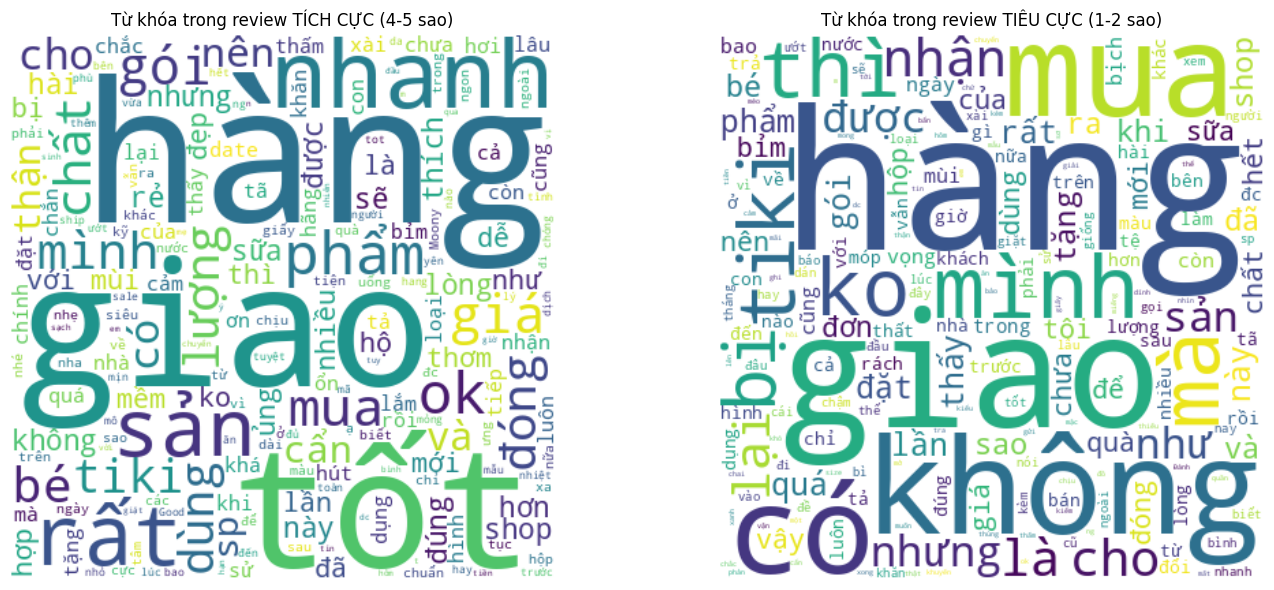

📊 Số lượng review tích cực/tiêu cực:
Tích cực (>=4 sao): 24918
Tiêu cực (<=2 sao): 2161


In [9]:
from wordcloud import WordCloud
import re

# Lấy content từ rating cao (4-5 sao) và thấp (1-2 sao)
high_reviews = df_reviews[df_reviews['rating'] >= 4]['content'].dropna().astype(str)
low_reviews = df_reviews[df_reviews['rating'] <= 2]['content'].dropna().astype(str)

text_high = ' '.join(high_reviews)
text_low = ' '.join(low_reviews)

# Vẽ wordcloud
fig, axes = plt.subplots(1,2, figsize=(15,6))
wordcloud_high = WordCloud(width=400, height=400, background_color='white', collocations=False).generate(text_high)
wordcloud_low = WordCloud(width=400, height=400, background_color='white', collocations=False).generate(text_low)

axes[0].imshow(wordcloud_high, interpolation='bilinear')
axes[0].set_title('Từ khóa trong review TÍCH CỰC (4-5 sao)')
axes[0].axis('off')

axes[1].imshow(wordcloud_low, interpolation='bilinear')
axes[1].set_title('Từ khóa trong review TIÊU CỰC (1-2 sao)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print("📊 Số lượng review tích cực/tiêu cực:")
print(f"Tích cực (>=4 sao): {len(high_reviews)}")
print(f"Tiêu cực (<=2 sao): {len(low_reviews)}")

Biểu đồ phân tích thời gian đánh giá (theo tháng) – xu hướng gần đây

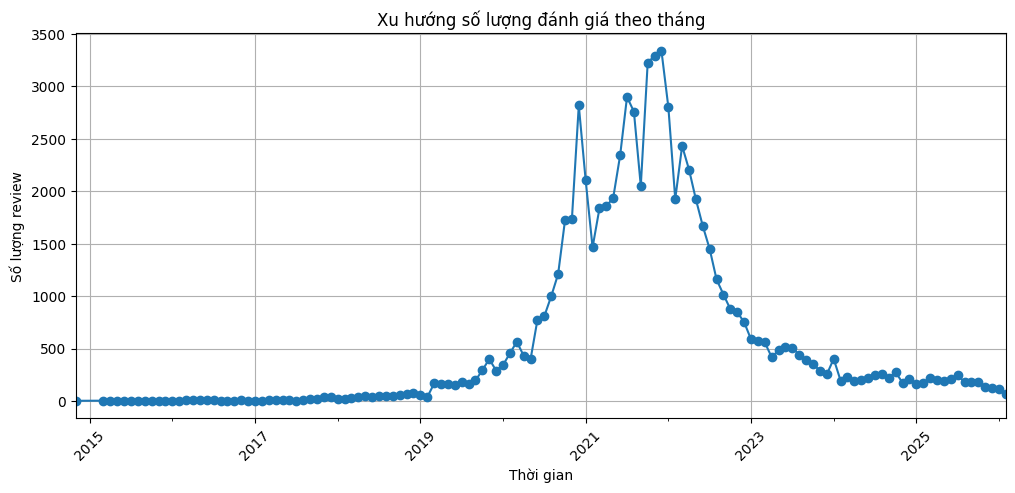

📊 Tháng có nhiều review nhất: 2021-12 với 3338 review
📊 Tháng gần nhất có dữ liệu: 2026-02


In [11]:
df_reviews['created_at_date'] = pd.to_datetime(df_reviews['created_at_date'])
df_reviews['month_year'] = df_reviews['created_at_date'].dt.to_period('M')
monthly_reviews = df_reviews.groupby('month_year').size()

plt.figure(figsize=(12,5))
monthly_reviews.plot(kind='line', marker='o')
plt.title('Xu hướng số lượng đánh giá theo tháng')
plt.xlabel('Thời gian')
plt.ylabel('Số lượng review')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

print("📊 Tháng có nhiều review nhất:", monthly_reviews.idxmax(), "với", monthly_reviews.max(), "review")
print("📊 Tháng gần nhất có dữ liệu:", monthly_reviews.index[-1])

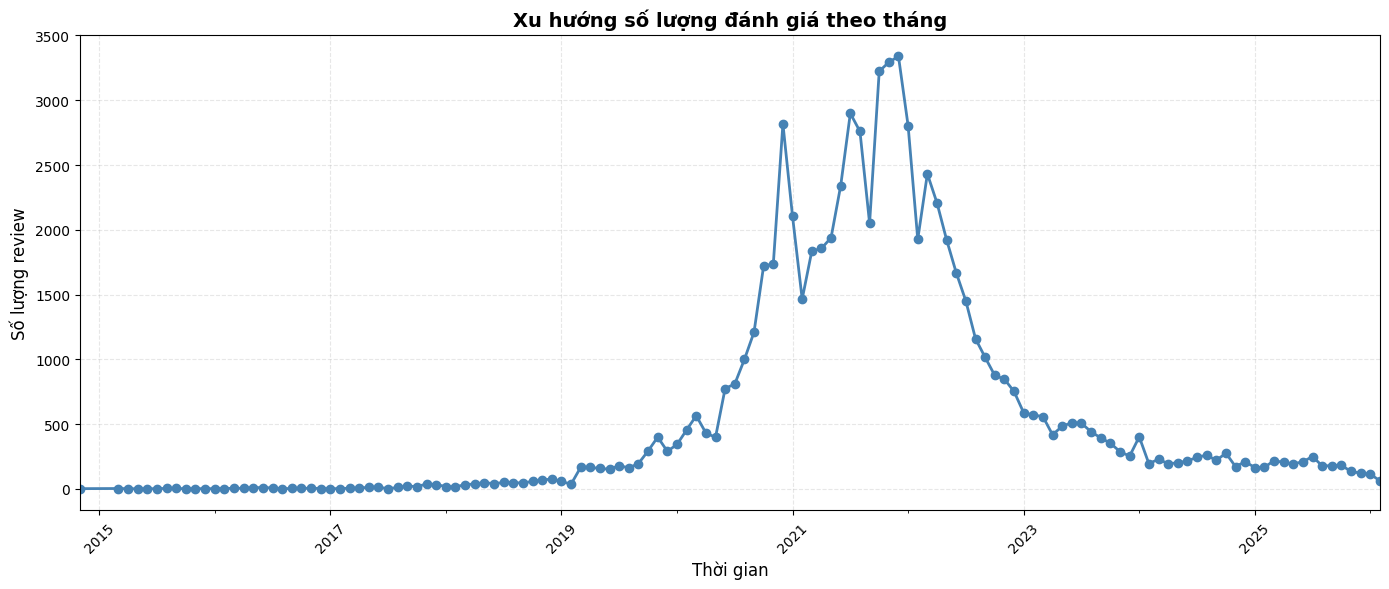


📊 PHÂN TÍCH SỐ LƯỢNG REVIEW THEO TỪNG NĂM

📌 NĂM 2014:
   ✅ Tháng có nhiều review nhất: 2014-11 - 2 review
   ❌ Tháng có ít review nhất: 2014-11 - 2 review
   📊 Trung bình: 2 review/tháng
   📈 Chênh lệch max - min: 0 review
   📉 Tỷ lệ chênh lệch: 0.0%

📌 NĂM 2015:
   ✅ Tháng có nhiều review nhất: 2015-08 - 4 review
   ❌ Tháng có ít review nhất: 2015-05 - 1 review
   📊 Trung bình: 2 review/tháng
   📈 Chênh lệch max - min: 3 review
   📉 Tỷ lệ chênh lệch: 300.0%

📌 NĂM 2016:
   ✅ Tháng có nhiều review nhất: 2016-05 - 10 review
   ❌ Tháng có ít review nhất: 2016-08 - 1 review
   📊 Trung bình: 5 review/tháng
   📈 Chênh lệch max - min: 9 review
   📉 Tỷ lệ chênh lệch: 900.0%

📌 NĂM 2017:
   ✅ Tháng có nhiều review nhất: 2017-11 - 38 review
   ❌ Tháng có ít review nhất: 2017-01 - 1 review
   📊 Trung bình: 14 review/tháng
   📈 Chênh lệch max - min: 37 review
   📉 Tỷ lệ chênh lệch: 3700.0%

📌 NĂM 2018:
   ✅ Tháng có nhiều review nhất: 2018-12 - 76 review
   ❌ Tháng có ít review nhất: 2018-02 - 

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Chuyển đổi và xử lý dữ liệu
df_reviews['created_at_date'] = pd.to_datetime(df_reviews['created_at_date'])
df_reviews['month_year'] = df_reviews['created_at_date'].dt.to_period('M')
df_reviews['year'] = df_reviews['created_at_date'].dt.year

# Group theo month_year
monthly_reviews = df_reviews.groupby('month_year').size()

# Vẽ biểu đồ chính
plt.figure(figsize=(14, 6))
ax = monthly_reviews.plot(kind='line', marker='o', linewidth=2, markersize=6, color='steelblue')

# Thêm số liệu lên các điểm trên biểu đồ
for i, (date, count) in enumerate(monthly_reviews.items()):
    if i % 3 == 0 or count == monthly_reviews.max() or count == monthly_reviews.min():  # Hiển thị định kỳ hoặc điểm đặc biệt
        ax.annotate(f'{count}', xy=(i, count), xytext=(0, 10),
                    textcoords='offset points', ha='center', fontsize=8, alpha=0.7)

plt.title('Xu hướng số lượng đánh giá theo tháng', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Số lượng review', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ========== PHÂN TÍCH THEO TỪNG NĂM ==========
print("\n" + "="*80)
print("📊 PHÂN TÍCH SỐ LƯỢNG REVIEW THEO TỪNG NĂM")
print("="*80)

# Lấy danh sách các năm có dữ liệu
years = sorted(df_reviews['year'].unique())

for year in years:
    # Lọc dữ liệu theo năm
    yearly_data = monthly_reviews[monthly_reviews.index.year == year]

    if len(yearly_data) > 0:
        max_count = yearly_data.max()
        min_count = yearly_data.min()
        max_month = yearly_data.idxmax()
        min_month = yearly_data.idxmin()
        avg_count = yearly_data.mean()

        print(f"\n📌 NĂM {year}:")
        print(f"   ✅ Tháng có nhiều review nhất: {max_month} - {max_count:,} review")
        print(f"   ❌ Tháng có ít review nhất: {min_month} - {min_count:,} review")
        print(f"   📊 Trung bình: {avg_count:,.0f} review/tháng")
        print(f"   📈 Chênh lệch max - min: {max_count - min_count:,} review")
        print(f"   📉 Tỷ lệ chênh lệch: {(max_count/min_count - 1)*100:.1f}%")

# Tổng quan tất cả các năm
print("\n" + "="*80)
print("📊 TỔNG QUAN TẤT CẢ CÁC NĂM")
print("="*80)
print(f"📌 Tháng có nhiều review nhất toàn thời gian: {monthly_reviews.idxmax()} - {monthly_reviews.max():,} review")
print(f"📌 Tháng có ít review nhất toàn thời gian: {monthly_reviews.idxmin()} - {monthly_reviews.min():,} review")
print(f"📌 Tháng gần nhất có dữ liệu: {monthly_reviews.index[-1]}")

Biểu đồ Top sản phẩm tiềm năng cho hệ thống đề xuất

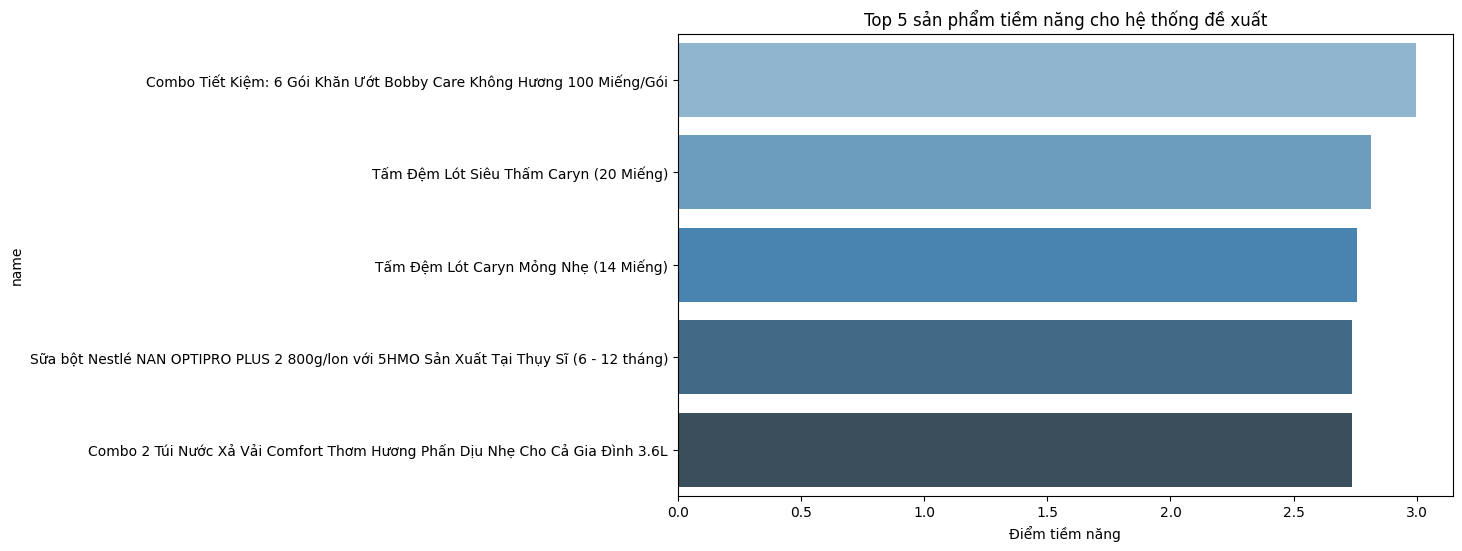

📋 Danh sách top 5 sản phẩm đề xuất:
                                                                                   name brand_name  rating_average  review_count    price  potential_score
                   Combo Tiết Kiệm: 6 Gói Khăn Ướt Bobby Care Không Hương 100 Miếng/Gói      Bobby             5.0        3034.0 198000.0         2.996204
                                                 Tấm Đệm Lót Siêu Thấm Caryn (20 Miếng)      Caryn             5.0        1191.0 121000.0         2.815446
                                                  Tấm Đệm Lót Caryn Mỏng Nhẹ (14 Miếng)      Caryn             5.0         578.0  99000.0         2.755254
Sữa bột Nestlé NAN OPTIPRO PLUS 2 800g/lon với 5HMO Sản Xuất Tại Thụy Sĩ (6 - 12 tháng)        NAN             5.0         473.0 512000.0         2.736954
           Combo 2 Túi Nước Xả Vải Comfort Thơm Hương Phấn Dịu Nhẹ Cho Cả Gia Đình 3.6L    Comfort             5.0         462.0 456000.0         2.736940


In [16]:
# Tính điểm tiềm năng (weighted score)
df_prod['potential_score'] = (
    df_prod['rating_average'] * 0.5 +
    (df_prod['review_count'] / df_prod['review_count'].max()) * 0.3 +
    (1 - (df_prod['price'] / df_prod['price'].max())) * 0.2
)

top_potential = df_prod.nlargest(5, 'potential_score')[['name','brand_name','rating_average','review_count','price','potential_score']]

plt.figure(figsize=(10,6))
sns.barplot(data=top_potential, y='name', x='potential_score', palette='Blues_d')
plt.title('Top 5 sản phẩm tiềm năng cho hệ thống đề xuất')
plt.xlabel('Điểm tiềm năng')
plt.show()

print("📋 Danh sách top 5 sản phẩm đề xuất:")
print(top_potential.head(5).to_string(index=False))